# TRABAJO FINAL UT5 - REGRESIÓN

**Dataset:** House Prices (Precios de viviendas)

**Objetivo:** Predecir el precio de venta (SalePrice) de viviendas basándose en diversas características.

En este trabajo voy a hacer un análisis completo de regresión con el dataset de precios de viviendas. Básicamente: preprocesar los datos, explorarlos un poco, probar varios modelos y ver cuál funciona mejor.

---
## 1. PREPROCESADO DE LOS DATOS
---

### 1.1 Importar librerías

In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


### 1.2 Importar dataset

In [ ]:
# Cargar el dataset
# Si usas Google Colab, primero sube el archivo house_prices_train.csv
# from google.colab import files
# files.upload()

dataset = pd.read_csv('house_prices_train.csv')

# Exploración inicial
print(f"Dimensiones del dataset: {dataset.shape}")
print(f"\nNúmero de filas: {dataset.shape[0]}")
print(f"Número de columnas: {dataset.shape[1]}")
dataset.head()

Dimensiones del dataset: (1460, 81)

Número de filas: 1460
Número de columnas: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Información del dataset
print("Información del dataset:")
print(dataset.info())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nul

In [ ]:
# Estadísticas descriptivas de las variables numéricas
dataset.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.3 Manejar datos missing (NaN)

Aquí toca ver qué columnas tienen valores nulos y decidir qué hacer con ellos.

In [ ]:
# Identificar columnas con valores nulos
missing_values = dataset.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columnas con valores missing:")
print(missing_values)
print(f"\nTotal de columnas con missing values: {len(missing_values)}")

Columnas con valores missing:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Total de columnas con missing values: 19


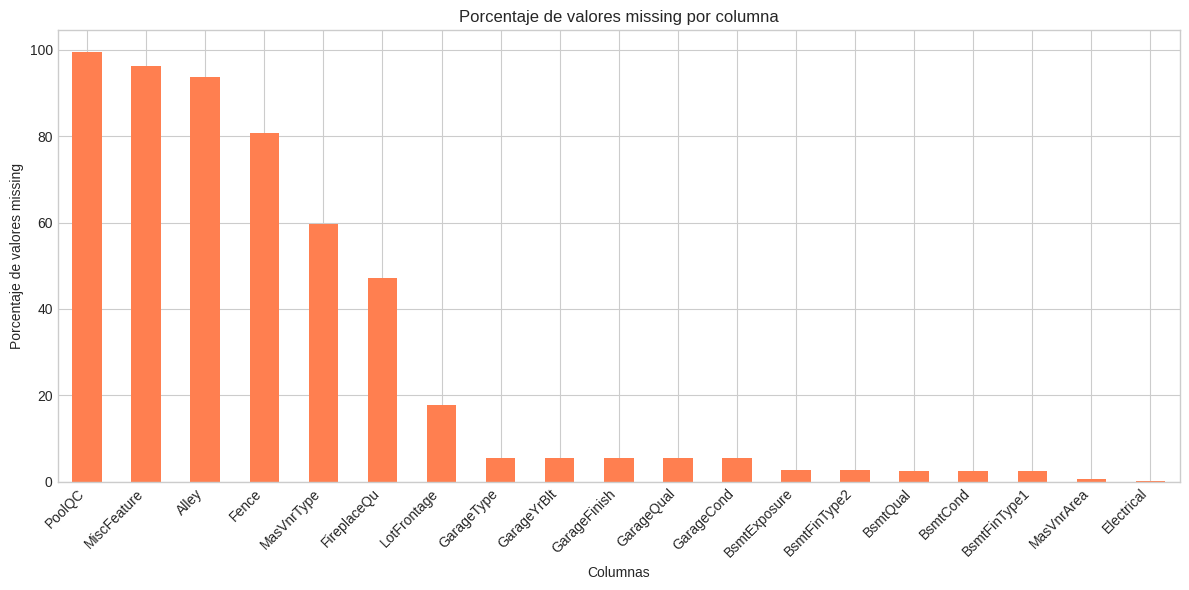

In [ ]:
# Visualización de valores missing
plt.figure(figsize=(12, 6))
missing_percent = (missing_values / len(dataset)) * 100
missing_percent.plot(kind='bar', color='coral')
plt.title('Porcentaje de valores missing por columna')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje de valores missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Seleccionar un subconjunto de variables relevantes para simplificar el análisis
# Esto también ayuda a manejar mejor los datos missing

# Variables numéricas importantes
numeric_features = ['LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
                    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
                    'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd',
                    'GarageCars', 'GarageArea']

# Variables categóricas importantes
categorical_features = ['MSZoning', 'Street', 'LotShape', 'LandContour',
                        'Neighborhood', 'BldgType', 'HouseStyle', 'CentralAir',
                        'KitchenQual', 'SaleCondition']

# Variable objetivo
target = 'SalePrice'

# Crear nuevo dataframe con las variables seleccionadas
selected_columns = numeric_features + categorical_features + [target]
df = dataset[selected_columns].copy()

print(f"Dataset reducido: {df.shape}")
print(f"\nValores missing en el dataset reducido:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset reducido: (1460, 25)

Valores missing en el dataset reducido:
Series([], dtype: int64)


In [ ]:
# Tratamiento de valores missing

# Para variables numéricas: imputar con la mediana
for col in numeric_features:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"{col}: imputado con mediana = {median_value}")

# Para variables categóricas: imputar con la moda
for col in categorical_features:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"{col}: imputado con moda = {mode_value}")

# Verificar que no quedan valores missing
print(f"\nTotal de valores missing después del tratamiento: {df.isnull().sum().sum()}")


Total de valores missing después del tratamiento: 0


### 1.4 Manejar datos categóricos

Las variables categóricas hay que pasarlas a números. Uso get_dummies que crea columnas binarias para cada categoría.

In [ ]:
# Ver las variables categóricas
print("Variables categóricas:")
for col in categorical_features:
    print(f"\n{col}: {df[col].nunique()} categorías")
    print(df[col].value_counts().head())

Variables categóricas:

MSZoning: 5 categorías
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street: 2 categorías
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

LotShape: 4 categorías
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour: 4 categorías
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Neighborhood: 25 categorías
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Name: count, dtype: int64

BldgType: 5 categorías
BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

HouseStyle: 8 categorías
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
Name: count, dtype: int64

CentralAir: 2 categorías
CentralAir
Y    1365
N      95
Name: count, dtype: int64

KitchenQual: 4 categorías
KitchenQual
TA    735

In [ ]:
# Aplicar One-Hot Encoding a las variables categóricas
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print(f"Dimensiones antes del encoding: {df.shape}")
print(f"Dimensiones después del encoding: {df_encoded.shape}")
df_encoded.head()

Dimensiones antes del encoding: (1460, 25)
Dimensiones después del encoding: (1460, 70)


,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,FullBath,HalfBath,...,HouseStyle_SLvl,CentralAir_Y,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,8450,7,5,2003,856,856,854,1710,2,1,...,False,True,False,True,False,False,False,False,True,False
1,9600,6,8,1976,1262,1262,0,1262,2,0,...,False,True,False,False,True,False,False,False,True,False
2,11250,7,5,2001,920,920,866,1786,2,1,...,False,True,False,True,False,False,False,False,True,False
3,9550,7,5,1915,756,961,756,1717,1,0,...,False,True,False,True,False,False,False,False,False,False
4,14260,8,5,2000,1145,1145,1053,2198,2,1,...,False,True,False,True,False,False,False,False,True,False


### 1.5 Evitar trampa de las variables dummy

El problema con las dummies es que si pones todas las categorías, la última se puede calcular a partir de las otras (si no es A ni B ni C, pues es D). Esto genera multicolinealidad y fastidia los modelos lineales.

La solución es quitar una categoría con drop_first=True.

In [ ]:
# Verificamos que se aplicó drop_first correctamente
# Por ejemplo, para 'CentralAir' que tiene 2 categorías (N, Y)
# Solo debería quedar una columna dummy

central_air_cols = [col for col in df_encoded.columns if 'CentralAir' in col]
print(f"Columnas dummy para CentralAir: {central_air_cols}")
print("\nSe eliminó una categoría (la primera) para evitar la trampa de las variables dummy.")
print("Esto se aplicó a todas las variables categóricas mediante drop_first=True.")

Columnas dummy para CentralAir: ['CentralAir_Y']

Se eliminó una categoría (la primera) para evitar la trampa de las variables dummy.
Esto se aplicó a todas las variables categóricas mediante drop_first=True.


### 1.6 Separar datos en conjuntos de entrenamiento y test

In [ ]:
# Separar variables independientes (X) y dependiente (y)
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

print(f"Variables independientes (X): {X.shape}")
print(f"Variable dependiente (y): {y.shape}")

Variables independientes (X): (1460, 69)
Variable dependiente (y): (1460,)


In [ ]:
# Dividir en train y test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de test: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 1168 muestras
Conjunto de test: 292 muestras


### 1.7 Estandarizar los datos

Estandarizo para que todas las variables estén en la misma escala (media 0, std 1).

$$x_{standar} = \frac{x - mean(x)}{std(x)}$$

Esto es importante sobre todo para SVR que se vuelve loco si las escalas son muy diferentes.

In [ ]:
# Aplicar StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit y transform solo con datos de entrenamiento
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)  # Solo transform, no fit

# Para SVR también necesitamos escalar y
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print("Datos estandarizados correctamente.")
print(f"\nMedia de X_train_scaled: {X_train_scaled.mean():.6f}")
print(f"Desviación estándar de X_train_scaled: {X_train_scaled.std():.6f}")

Datos estandarizados correctamente.

Media de X_train_scaled: -0.000000
Desviación estándar de X_train_scaled: 1.000000


---
## 2. EDA BÁSICO - Análisis Exploratorio
---

### 2.1 Distribución de la variable objetivo

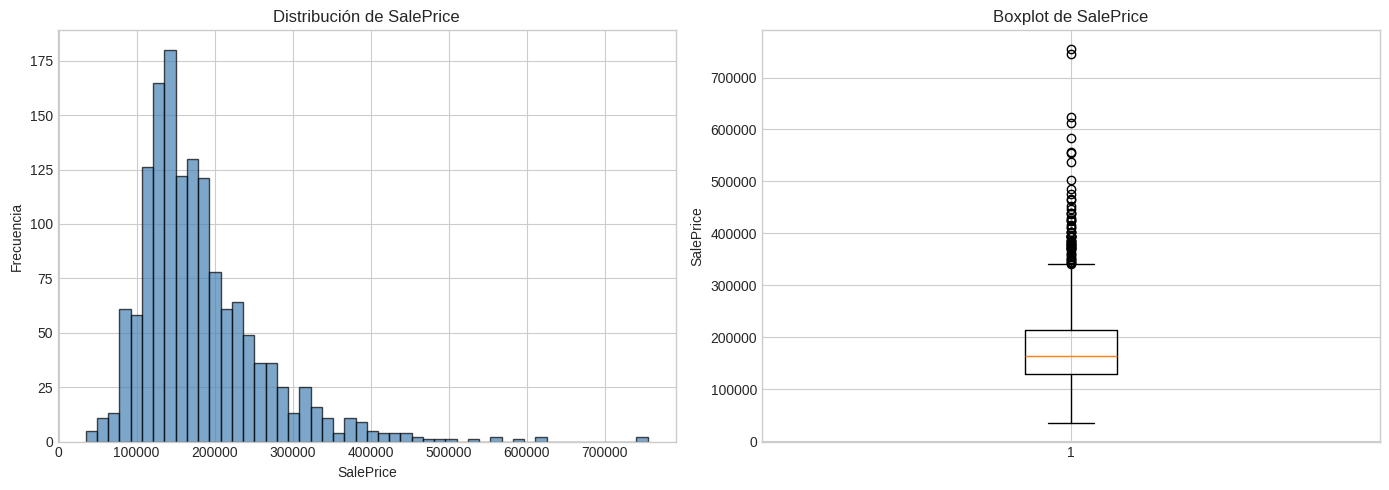

Estadísticas de SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [ ]:
# Distribución de SalePrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(y, vert=True)
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

print(f"Estadísticas de SalePrice:")
print(y.describe())

### 2.2 Análisis de correlaciones

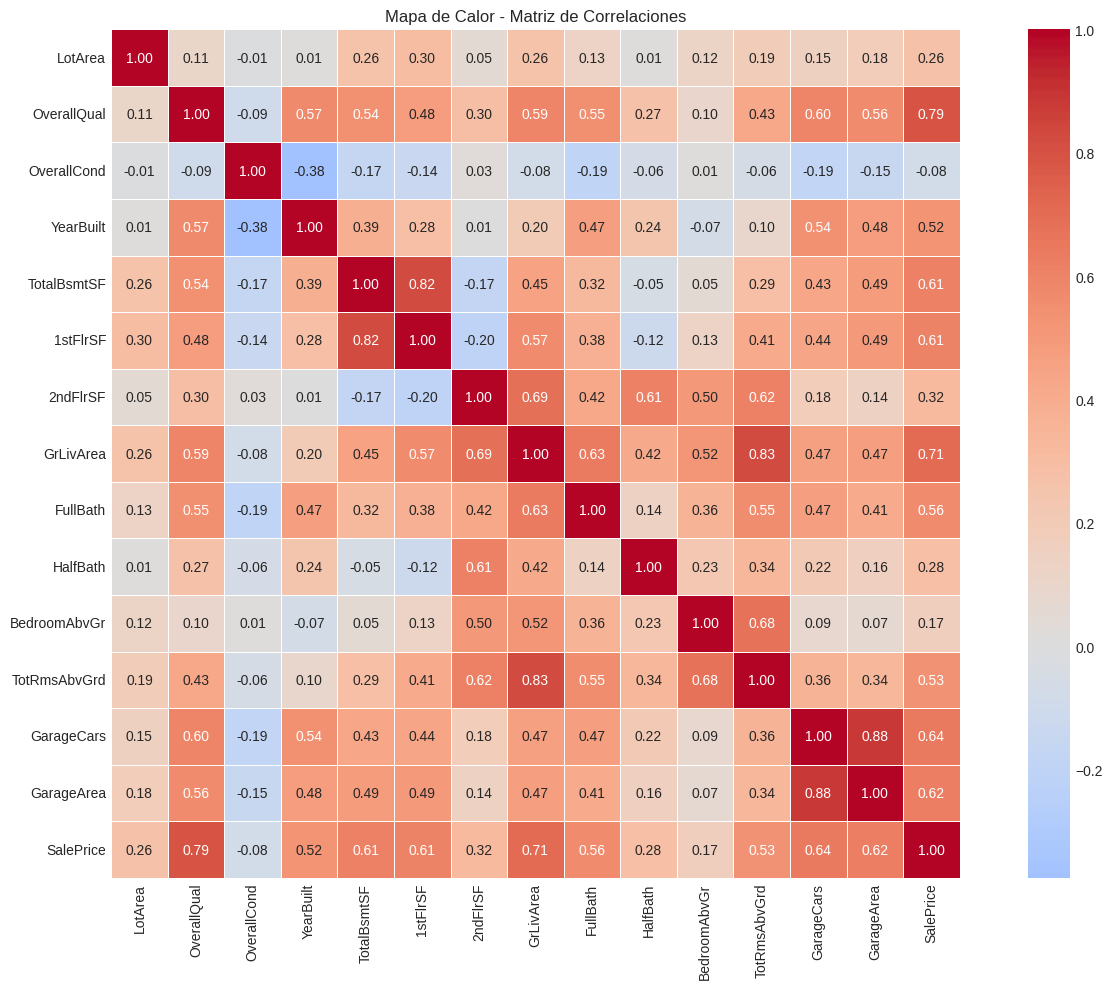

In [ ]:
# Matriz de correlación de las variables numéricas originales
numeric_cols = numeric_features + [target]
correlation_matrix = df[numeric_cols].corr()

# Mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Mapa de Calor - Matriz de Correlaciones')
plt.tight_layout()
plt.show()

Top 10 variables más correlacionadas con SalePrice:

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
2ndFlrSF        0.319334
Name: SalePrice, dtype: float64


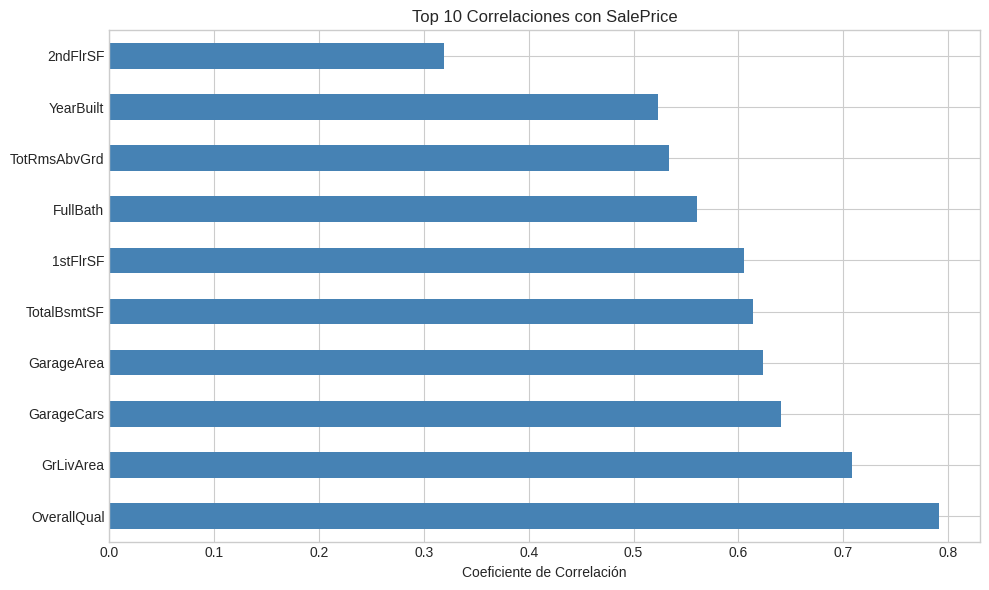

In [ ]:
# Top 10 variables más correlacionadas con SalePrice
correlations_with_target = correlation_matrix[target].drop(target).sort_values(ascending=False)

print("Top 10 variables más correlacionadas con SalePrice:\n")
print(correlations_with_target.head(10))

# Visualización
plt.figure(figsize=(10, 6))
correlations_with_target.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Correlaciones con SalePrice')
plt.xlabel('Coeficiente de Correlación')
plt.tight_layout()
plt.show()

### 2.3 Pairplot de variables más importantes

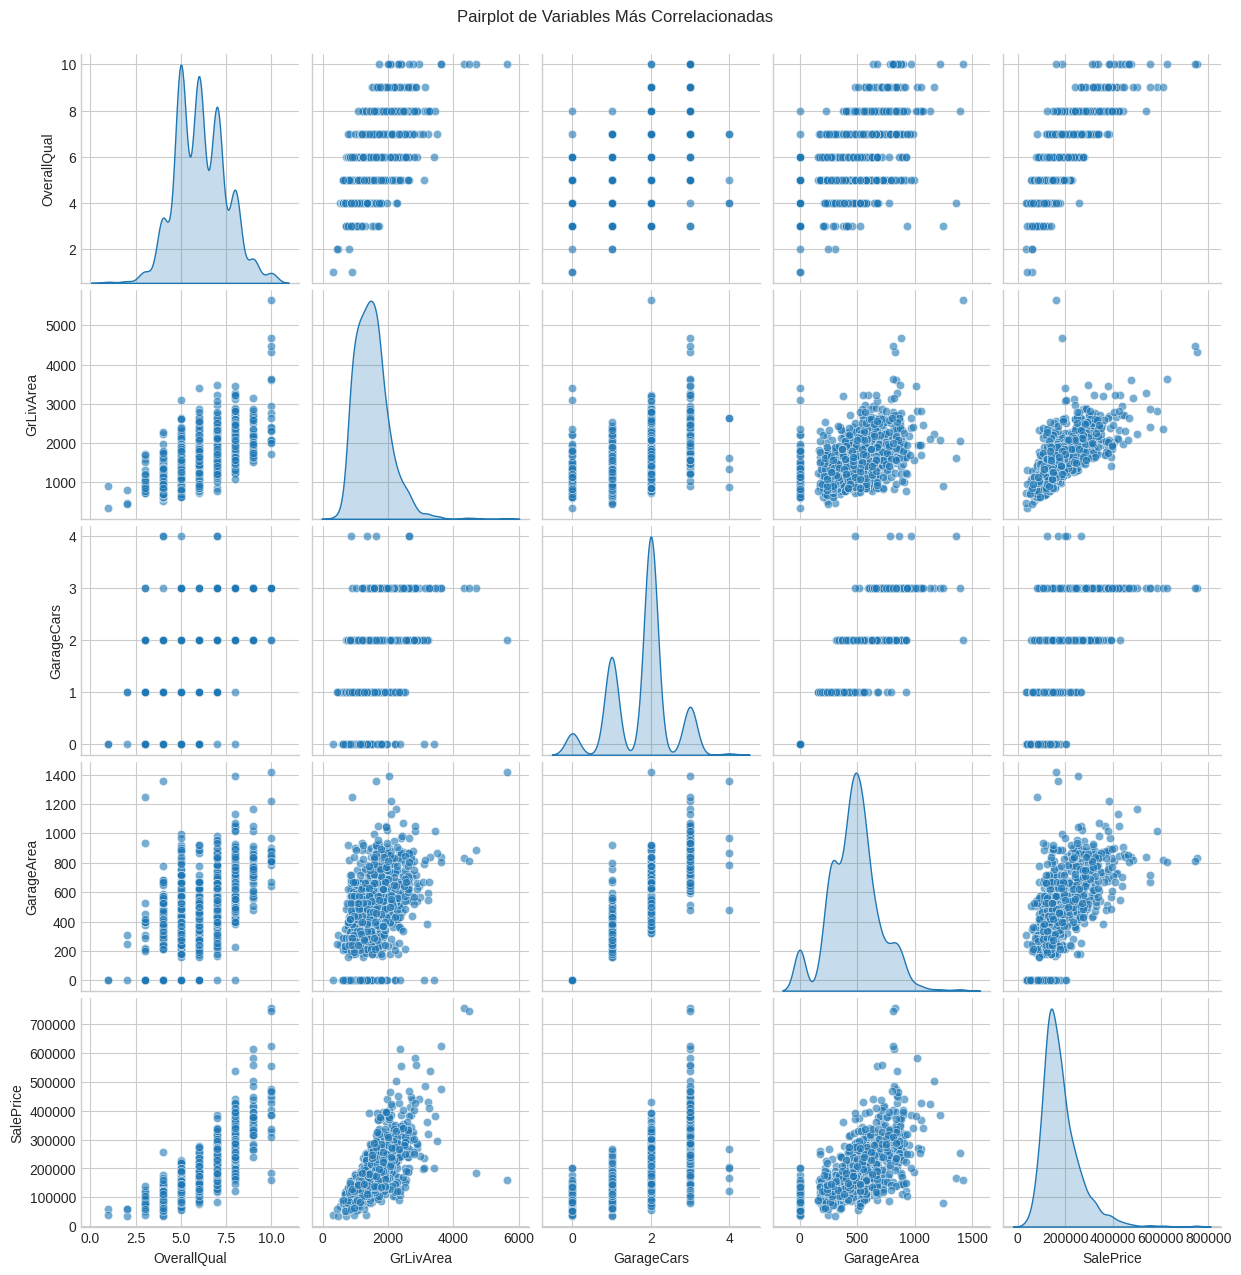

In [ ]:
# Pairplot de las 4 variables más correlacionadas con SalePrice
top_features = correlations_with_target.head(4).index.tolist() + [target]

sns.pairplot(df[top_features], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot de Variables Más Correlacionadas', y=1.02)
plt.show()

### 2.4 Conclusiones del EDA

Lo que he visto en los datos:

- SalePrice está sesgado a la derecha, hay bastantes casas baratas y pocas muy caras. Es normal en precios de viviendas.

- Las variables que más correlacionan con el precio son OverallQual (0.79) y GrLivArea (0.71). Tiene sentido porque la calidad y el tamaño son lo que más importa al comprar casa.

- GarageCars y GarageArea correlacionan entre ellas (lógico, más coches = más área de garaje). Hay que tenerlo en cuenta pero no es un problema grave.

- En general la relación parece bastante lineal, aunque hay dispersión.

---
## 3. REGRESIÓN LINEAL MÚLTIPLE
---

In [ ]:
# Crear y entrenar el modelo de regresión lineal
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predicciones
y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

print("Modelo de Regresión Lineal Múltiple entrenado.")
print(f"\nIntercepto (b0): {lr_model.intercept_:.2f}")
print(f"Número de coeficientes: {len(lr_model.coef_)}")

Modelo de Regresión Lineal Múltiple entrenado.

Intercepto (b0): -744682.33
Número de coeficientes: 69


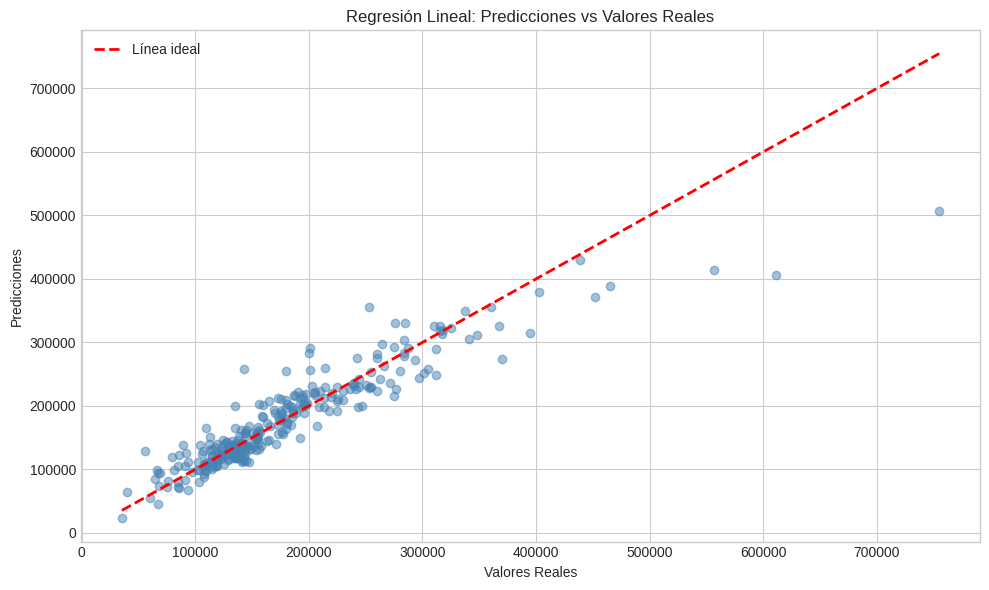

In [ ]:
# Visualización de predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr_test, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal: Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Predicción para nuevos valores
# Tomamos una muestra del dataset y predecimos
new_samples = X_test.iloc[:5]
predictions_lr = lr_model.predict(new_samples)

print("Predicciones para nuevos valores (Regresión Lineal):")
for i, (pred, real) in enumerate(zip(predictions_lr, y_test.iloc[:5].values)):
    print(f"Muestra {i+1}: Predicción = ${pred:,.0f} | Real = ${real:,.0f}")

Predicciones para nuevos valores (Regresión Lineal):
Muestra 1: Predicción = $149,359 | Real = $154,500
Muestra 2: Predicción = $322,980 | Real = $325,000
Muestra 3: Predicción = $121,830 | Real = $115,000
Muestra 4: Predicción = $183,444 | Real = $159,000
Muestra 5: Predicción = $317,776 | Real = $315,500


---
## 4. MÁQUINAS DE SOPORTE VECTORIAL (SVR)
---

In [ ]:
# SVR requiere datos escalados
# Usar kernel RBF (Radial Basis Function)

svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# Predicciones (hay que invertir la escala)
y_pred_svr_train_scaled = svr_model.predict(X_train_scaled)
y_pred_svr_test_scaled = svr_model.predict(X_test_scaled)

# Invertir la transformación para obtener valores originales
y_pred_svr_train = scaler_y.inverse_transform(y_pred_svr_train_scaled.reshape(-1, 1)).ravel()
y_pred_svr_test = scaler_y.inverse_transform(y_pred_svr_test_scaled.reshape(-1, 1)).ravel()

print("Modelo SVR (kernel RBF) entrenado.")
print(f"Parámetro C (regularización): {svr_model.C}")
print(f"Kernel: {svr_model.kernel}")

Modelo SVR (kernel RBF) entrenado.
Parámetro C (regularización): 100
Kernel: rbf


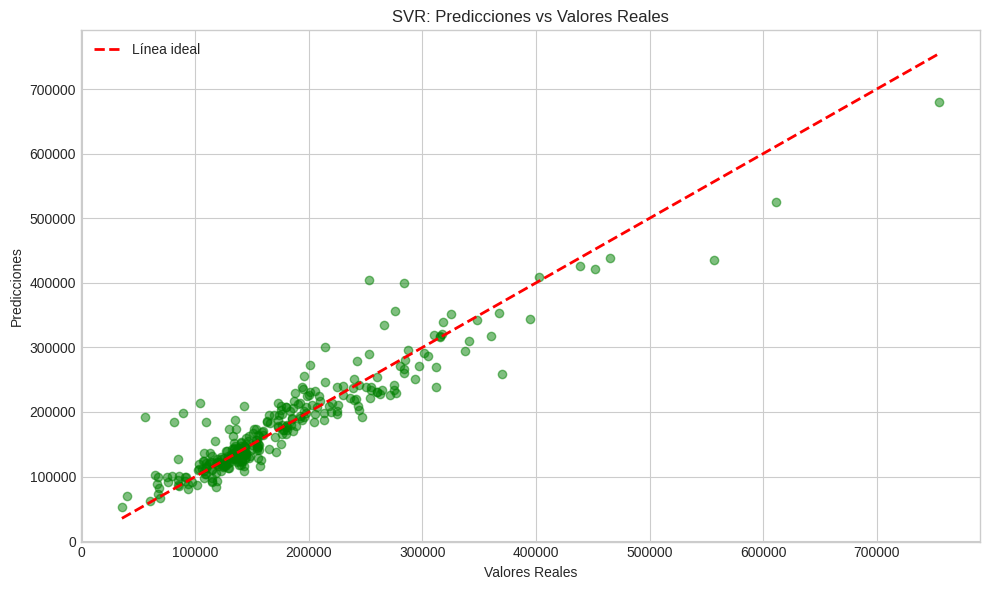

In [ ]:
# Visualización de predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_svr_test, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('SVR: Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Predicción para nuevos valores
new_samples_scaled = X_test_scaled[:5]
predictions_svr_scaled = svr_model.predict(new_samples_scaled)
predictions_svr = scaler_y.inverse_transform(predictions_svr_scaled.reshape(-1, 1)).ravel()

print("Predicciones para nuevos valores (SVR):")
for i, (pred, real) in enumerate(zip(predictions_svr, y_test.iloc[:5].values)):
    print(f"Muestra {i+1}: Predicción = ${pred:,.0f} | Real = ${real:,.0f}")

Predicciones para nuevos valores (SVR):
Muestra 1: Predicción = $146,772 | Real = $154,500
Muestra 2: Predicción = $352,328 | Real = $325,000
Muestra 3: Predicción = $110,775 | Real = $115,000
Muestra 4: Predicción = $169,711 | Real = $159,000
Muestra 5: Predicción = $315,994 | Real = $315,500


---
## 5. ÁRBOLES DE DECISIÓN
---

In [ ]:
# Crear y entrenar el árbol de decisión
# Limitamos la profundidad para evitar overfitting
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predicciones
y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

print("Modelo de Árbol de Decisión entrenado.")
print(f"Profundidad máxima: {dt_model.max_depth}")
print(f"Profundidad real del árbol: {dt_model.get_depth()}")
print(f"Número de hojas: {dt_model.get_n_leaves()}")

Modelo de Árbol de Decisión entrenado.
Profundidad máxima: 10
Profundidad real del árbol: 10
Número de hojas: 174


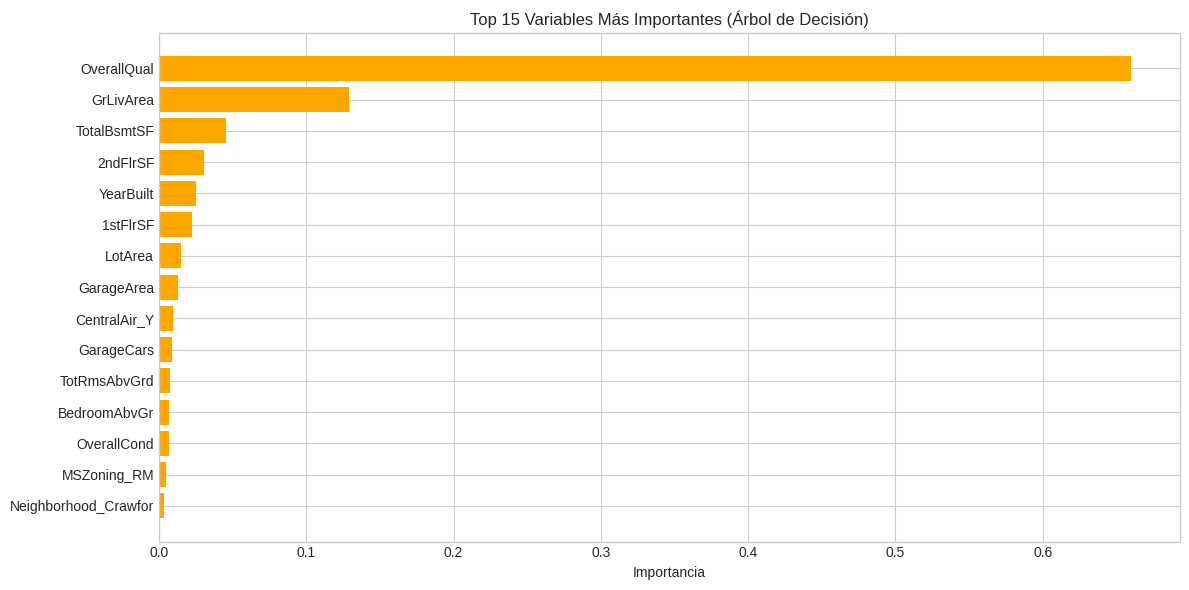

In [ ]:
# Importancia de las características
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15), color='orange')
plt.xlabel('Importancia')
plt.title('Top 15 Variables Más Importantes (Árbol de Decisión)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

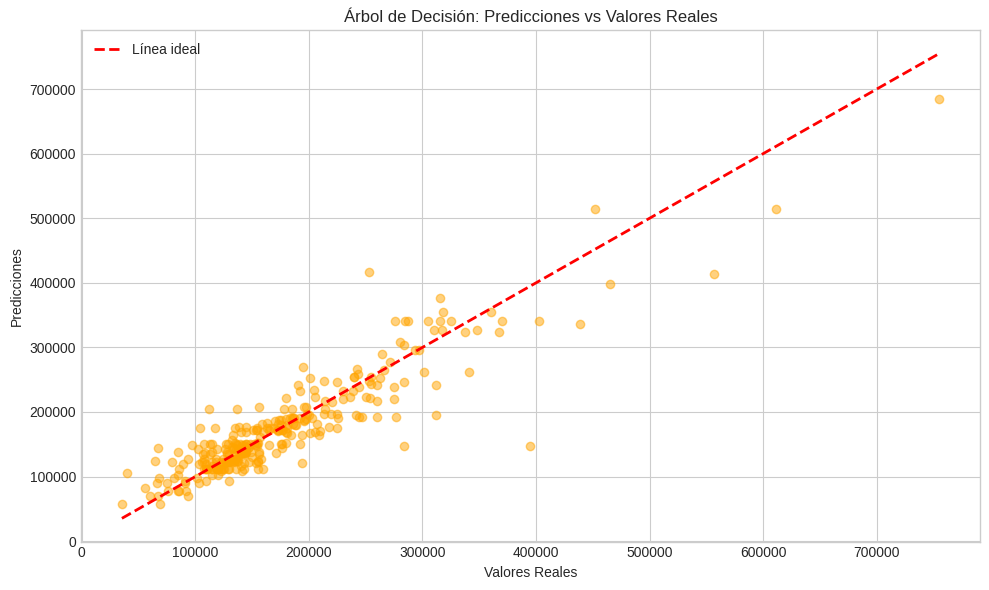

In [ ]:
# Visualización de predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt_test, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Árbol de Decisión: Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Predicción para nuevos valores
predictions_dt = dt_model.predict(new_samples)

print("Predicciones para nuevos valores (Árbol de Decisión):")
for i, (pred, real) in enumerate(zip(predictions_dt, y_test.iloc[:5].values)):
    print(f"Muestra {i+1}: Predicción = ${pred:,.0f} | Real = ${real:,.0f}")

Predicciones para nuevos valores (Árbol de Decisión):
Muestra 1: Predicción = $146,811 | Real = $154,500
Muestra 2: Predicción = $340,478 | Real = $325,000
Muestra 3: Predicción = $117,100 | Real = $115,000
Muestra 4: Predicción = $182,171 | Real = $159,000
Muestra 5: Predicción = $375,750 | Real = $315,500


---
## 6. BOSQUES ALEATORIOS (Random Forest)
---

In [ ]:
# Crear y entrenar el Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15,
                                  min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

print("Modelo de Bosques Aleatorios entrenado.")
print(f"Número de árboles: {rf_model.n_estimators}")
print(f"Profundidad máxima: {rf_model.max_depth}")

Modelo de Bosques Aleatorios entrenado.
Número de árboles: 100
Profundidad máxima: 15


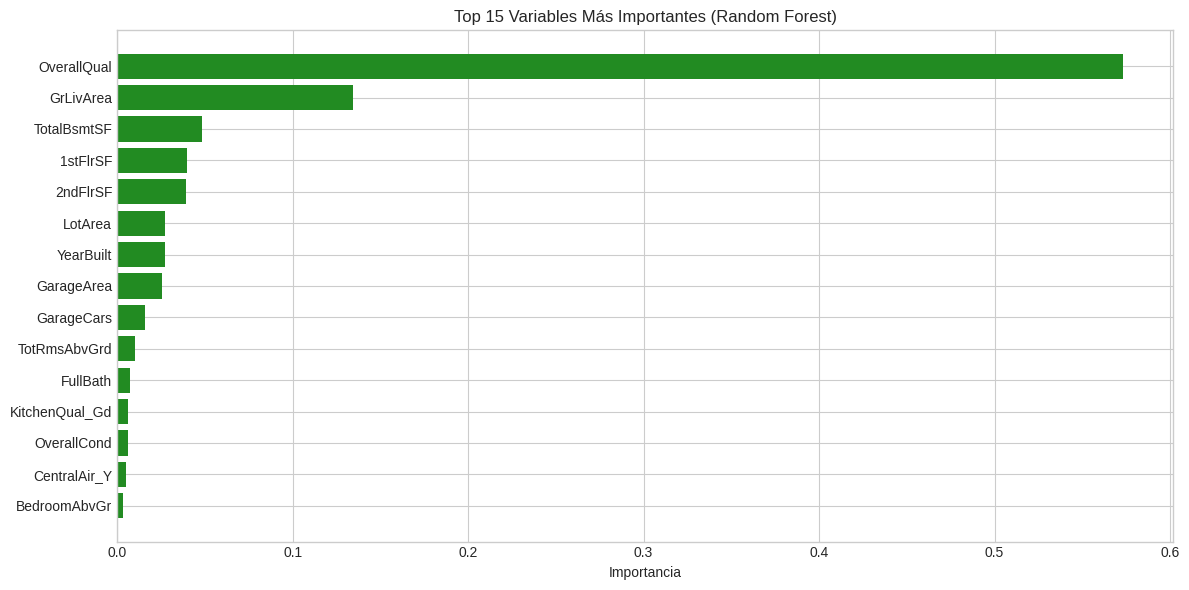

In [ ]:
# Importancia de las características (Random Forest)
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance_rf['feature'].head(15), feature_importance_rf['importance'].head(15), color='forestgreen')
plt.xlabel('Importancia')
plt.title('Top 15 Variables Más Importantes (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

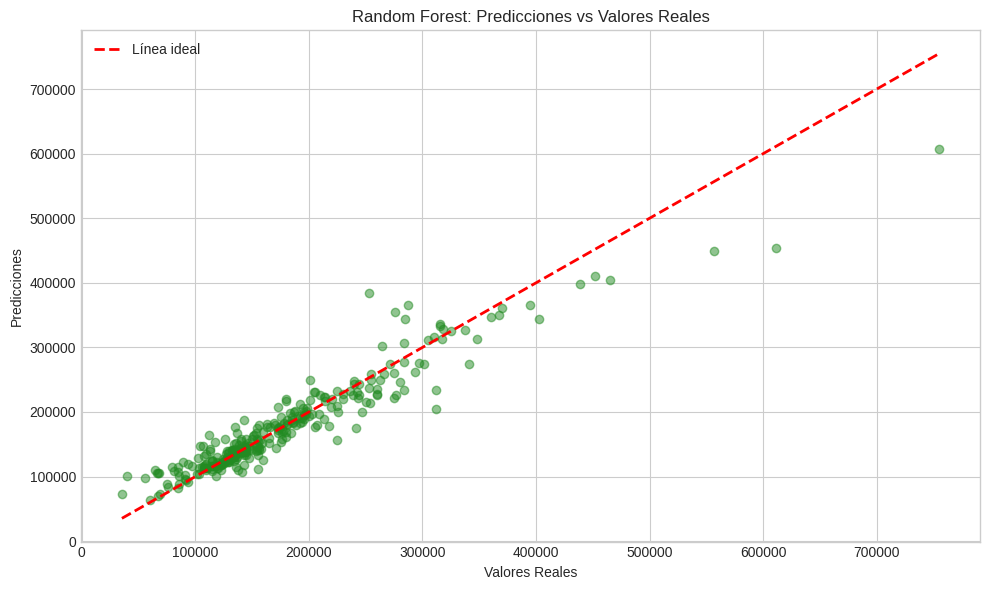

In [ ]:
# Visualización de predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf_test, alpha=0.5, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea ideal')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Random Forest: Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Predicción para nuevos valores
predictions_rf = rf_model.predict(new_samples)

print("Predicciones para nuevos valores (Random Forest):")
for i, (pred, real) in enumerate(zip(predictions_rf, y_test.iloc[:5].values)):
    print(f"Muestra {i+1}: Predicción = ${pred:,.0f} | Real = ${real:,.0f}")

Predicciones para nuevos valores (Random Forest):
Muestra 1: Predicción = $141,317 | Real = $154,500
Muestra 2: Predicción = $325,834 | Real = $325,000
Muestra 3: Predicción = $116,808 | Real = $115,000
Muestra 4: Predicción = $152,436 | Real = $159,000
Muestra 5: Predicción = $332,945 | Real = $315,500


---
## 7. EDA - ANÁLISIS DE RESIDUOS Y OVERFITTING
---

### 7.1 Análisis de Residuos

El residuo es la diferencia entre el valor real y el valor predicho:
$$residuo = y_{real} - y_{pred}$$

In [ ]:
# Calcular residuos para todos los modelos
residuals = {
    'Linear Regression': y_test.values - y_pred_lr_test,
    'SVR': y_test.values - y_pred_svr_test,
    'Decision Tree': y_test.values - y_pred_dt_test,
    'Random Forest': y_test.values - y_pred_rf_test
}

predictions = {
    'Linear Regression': y_pred_lr_test,
    'SVR': y_pred_svr_test,
    'Decision Tree': y_pred_dt_test,
    'Random Forest': y_pred_rf_test
}

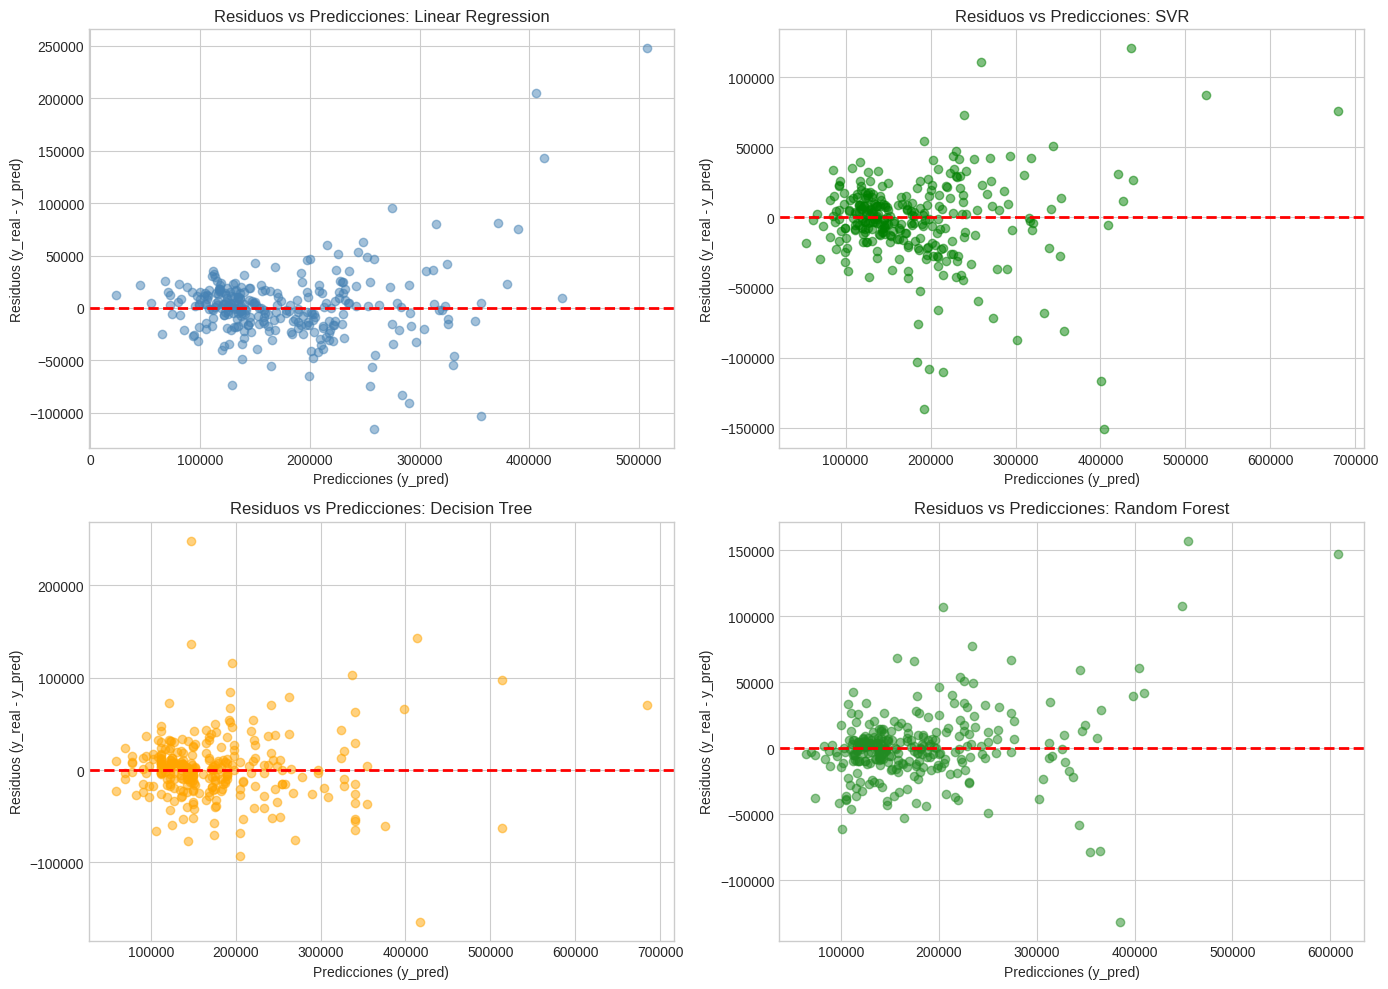

In [ ]:
# Gráfico de residuos vs predicciones para cada modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['steelblue', 'green', 'orange', 'forestgreen']

for ax, (name, res), color in zip(axes, residuals.items(), colors):
    pred = predictions[name]
    ax.scatter(pred, res, alpha=0.5, color=color)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicciones (y_pred)')
    ax.set_ylabel('Residuos (y_real - y_pred)')
    ax.set_title(f'Residuos vs Predicciones: {name}')

plt.tight_layout()
plt.show()

### 7.2 Determinar si hay Overfitting

Overfitting es cuando el modelo memoriza los datos de entrenamiento en vez de aprender patrones generales. Se nota porque el error en train es muy bajo pero en test sube bastante.

Para detectarlo comparo el MSE de train vs test. Si test es mucho mayor (pongo un umbral de 1.5x), hay overfitting.


In [ ]:
# Calcular MSE para train y test de cada modelo
print("Análisis de Overfitting (MSE):")
print("="*60)

models_analysis = [
    ('Linear Regression', y_pred_lr_train, y_pred_lr_test),
    ('SVR', y_pred_svr_train, y_pred_svr_test),
    ('Decision Tree', y_pred_dt_train, y_pred_dt_test),
    ('Random Forest', y_pred_rf_train, y_pred_rf_test)
]

overfitting_results = []

for name, pred_train, pred_test in models_analysis:
    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)
    ratio = mse_test / mse_train

    overfitting = "SÍ" if mse_test > mse_train * 1.5 else "NO"

    overfitting_results.append({
        'Modelo': name,
        'MSE Train': mse_train,
        'MSE Test': mse_test,
        'Ratio (Test/Train)': ratio,
        'Overfitting': overfitting
    })

    print(f"\n{name}:")
    print(f"  MSE Train: {mse_train:,.0f}")
    print(f"  MSE Test:  {mse_test:,.0f}")
    print(f"  Ratio (Test/Train): {ratio:.2f}")
    print(f"  ¿Overfitting?: {overfitting}")

# Tabla resumen
print("\n" + "="*60)
overfitting_df = pd.DataFrame(overfitting_results)
overfitting_df

Análisis de Overfitting (MSE):

Linear Regression:
  MSE Train: 861,538,186
  MSE Test:  1,116,638,902
  Ratio (Test/Train): 1.30
  ¿Overfitting?: NO

SVR:
  MSE Train: 59,105,988
  MSE Test:  953,173,152
  Ratio (Test/Train): 16.13
  ¿Overfitting?: SÍ

Decision Tree:
  MSE Train: 229,417,573
  MSE Test:  1,322,913,848
  Ratio (Test/Train): 5.77
  ¿Overfitting?: SÍ

Random Forest:
  MSE Train: 180,308,298
  MSE Test:  784,355,549
  Ratio (Test/Train): 4.35
  ¿Overfitting?: SÍ



,Modelo,MSE Train,MSE Test,Ratio (Test/Train),Overfitting
0,Linear Regression,8.615382e+08,1.116639e+09,1.296099,NO
1,SVR,5.910599e+07,9.531732e+08,16.126507,SÍ
2,Decision Tree,2.294176e+08,1.322914e+09,5.766402,SÍ
3,Random Forest,1.803083e+08,7.843555e+08,4.350080,SÍ


### 7.3 Normalizar la distribución aplicando el logaritmo

Como vimos antes, SalePrice está bastante sesgado (muchas casas baratas, pocas caras). Una forma de arreglarlo es aplicar el logaritmo.

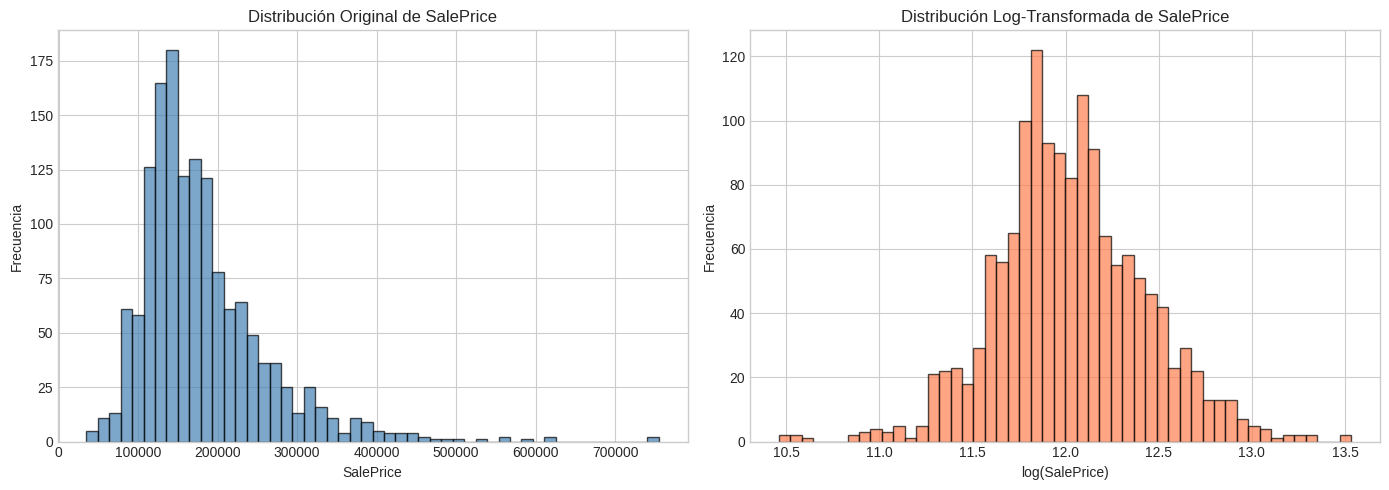

La transformación logarítmica ayuda a normalizar distribuciones sesgadas.
Esto puede mejorar el rendimiento de modelos que asumen normalidad en los residuos.


In [ ]:
# Comparar distribución original vs log-transformada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
axes[0].hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución Original de SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frecuencia')

# Distribución log-transformada
y_log = np.log1p(y)  # log(1+x) para evitar log(0)
axes[1].hist(y_log, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución Log-Transformada de SalePrice')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("La transformación logarítmica ayuda a normalizar distribuciones sesgadas.")
print("Esto puede mejorar el rendimiento de modelos que asumen normalidad en los residuos.")

---
## 8. MÉTRICAS Y COMPARACIÓN DE RESULTADOS (1 punto)
---

### 8.1 Cálculo de métricas

Uso estas métricas para comparar los modelos:

- MSE: error cuadrático medio, penaliza más los errores grandes
- MAE: error absoluto medio, más fácil de interpretar (en dólares directamente)
- R²: cuánto explica el modelo, 1 es perfecto y 0 es malo
- R² Ajustado: como R² pero penaliza meter muchas variables


In [ ]:
# Función para calcular R² ajustado
def adjusted_r2(r2, n, k):
    """Calcula R² ajustado
    n: número de observaciones
    k: número de variables independientes
    """
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Número de características
n_features = X_test.shape[1]
n_samples = X_test.shape[0]

# Calcular todas las métricas para cada modelo
metrics_results = []

for name, pred_test in predictions.items():
    mse = mean_squared_error(y_test, pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)
    r2_adj = adjusted_r2(r2, n_samples, n_features)

    metrics_results.append({
        'Modelo': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'R² Ajustado': r2_adj
    })

# Crear DataFrame con resultados
metrics_df = pd.DataFrame(metrics_results)
metrics_df = metrics_df.set_index('Modelo')

print("Métricas de Evaluación de Modelos (conjunto de test):")
print("="*70)
metrics_df

Métricas de Evaluación de Modelos (conjunto de test):


,MSE,RMSE,MAE,R²,R² Ajustado
Modelo,,,,,
Linear Regression,1.116639e+09,33416.147317,20549.312082,0.854421,0.809173
SVR,9.531732e+08,30873.502427,20260.689290,0.875732,0.837109
Decision Tree,1.322914e+09,36371.882659,23721.261815,0.827528,0.773922
Random Forest,7.843555e+08,28006.348367,17418.807565,0.897742,0.865959


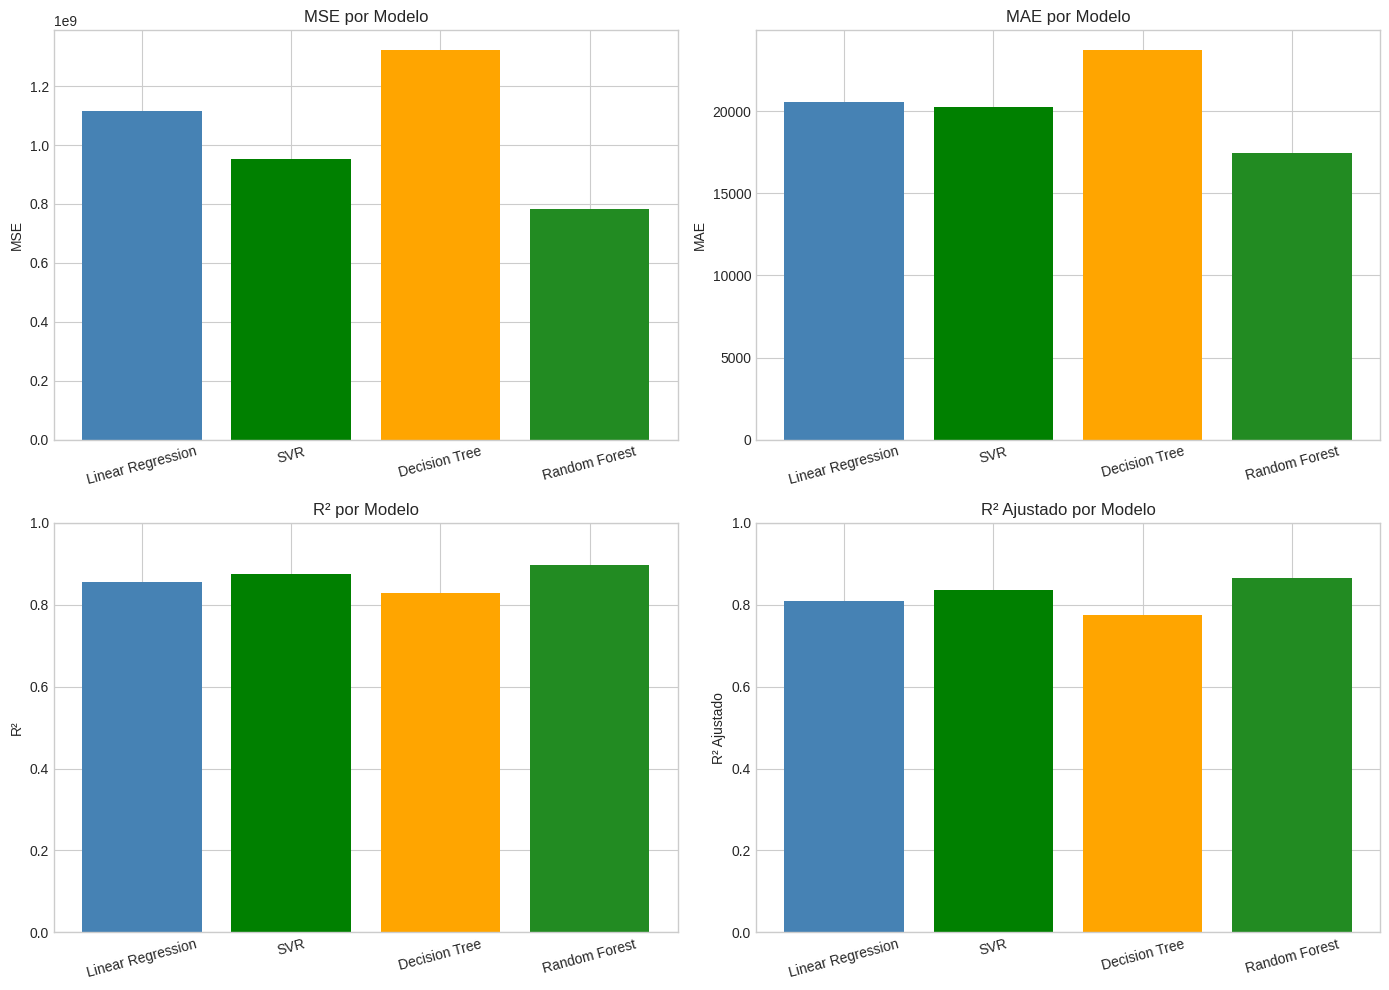

In [ ]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['steelblue', 'green', 'orange', 'forestgreen']
models = metrics_df.index.tolist()

# MSE
axes[0, 0].bar(models, metrics_df['MSE'], color=colors)
axes[0, 0].set_title('MSE por Modelo')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].tick_params(axis='x', rotation=15)

# MAE
axes[0, 1].bar(models, metrics_df['MAE'], color=colors)
axes[0, 1].set_title('MAE por Modelo')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].tick_params(axis='x', rotation=15)

# R²
axes[1, 0].bar(models, metrics_df['R²'], color=colors)
axes[1, 0].set_title('R² por Modelo')
axes[1, 0].set_ylabel('R²')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].set_ylim(0, 1)

# R² Ajustado
axes[1, 1].bar(models, metrics_df['R² Ajustado'], color=colors)
axes[1, 1].set_title('R² Ajustado por Modelo')
axes[1, 1].set_ylabel('R² Ajustado')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 8.2 Ensemble Prediction

La idea del ensemble es combinar todos los modelos haciendo la media de sus predicciones. A veces funciona mejor que cualquier modelo individual porque los errores de unos se compensan con otros, una predicción mas robusta.


In [ ]:
# Calcular predicción ensemble (media de todos los modelos)
y_pred_ensemble = (y_pred_lr_test + y_pred_svr_test + y_pred_dt_test + y_pred_rf_test) / 4

# Calcular métricas del ensemble
mse_ensemble = mean_squared_error(y_test, y_pred_ensemble)
rmse_ensemble = np.sqrt(mse_ensemble)
mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)
r2_adj_ensemble = adjusted_r2(r2_ensemble, n_samples, n_features)

print("ENSEMBLE PREDICTION (Media de 4 modelos)")
print("="*50)
print(f"MSE:         {mse_ensemble:,.0f}")
print(f"RMSE:        {rmse_ensemble:,.0f}")
print(f"MAE:         {mae_ensemble:,.0f}")
print(f"R²:          {r2_ensemble:.4f}")
print(f"R² Ajustado: {r2_adj_ensemble:.4f}")

ENSEMBLE PREDICTION (Media de 4 modelos)
MSE:         737,261,887
RMSE:        27,153
MAE:         17,534
R²:          0.9039
R² Ajustado: 0.8740


In [ ]:
# Comparación final incluyendo el ensemble
# Añadir ensemble al DataFrame de métricas
ensemble_metrics = pd.DataFrame([{
    'Modelo': 'ENSEMBLE',
    'MSE': mse_ensemble,
    'RMSE': rmse_ensemble,
    'MAE': mae_ensemble,
    'R²': r2_ensemble,
    'R² Ajustado': r2_adj_ensemble
}]).set_index('Modelo')

final_metrics = pd.concat([metrics_df, ensemble_metrics])

print("COMPARACIÓN FINAL DE TODOS LOS MODELOS")
print("="*70)
final_metrics

COMPARACIÓN FINAL DE TODOS LOS MODELOS


,MSE,RMSE,MAE,R²,R² Ajustado
Modelo,,,,,
Linear Regression,1.116639e+09,33416.147317,20549.312082,0.854421,0.809173
SVR,9.531732e+08,30873.502427,20260.689290,0.875732,0.837109
Decision Tree,1.322914e+09,36371.882659,23721.261815,0.827528,0.773922
Random Forest,7.843555e+08,28006.348367,17418.807565,0.897742,0.865959
ENSEMBLE,7.372619e+08,27152.566856,17534.468181,0.903881,0.874007


In [ ]:
# Ranking de modelos por R²
ranking = final_metrics.sort_values('R²', ascending=False)

print("\nRANKING DE MODELOS (ordenado por R²):")
print("="*50)
for i, (model, row) in enumerate(ranking.iterrows(), 1):
    print(f"{i}. {model}: R² = {row['R²']:.4f}")


RANKING DE MODELOS (ordenado por R²):
1. ENSEMBLE: R² = 0.9039
2. Random Forest: R² = 0.8977
3. SVR: R² = 0.8757
4. Linear Regression: R² = 0.8544
5. Decision Tree: R² = 0.8275


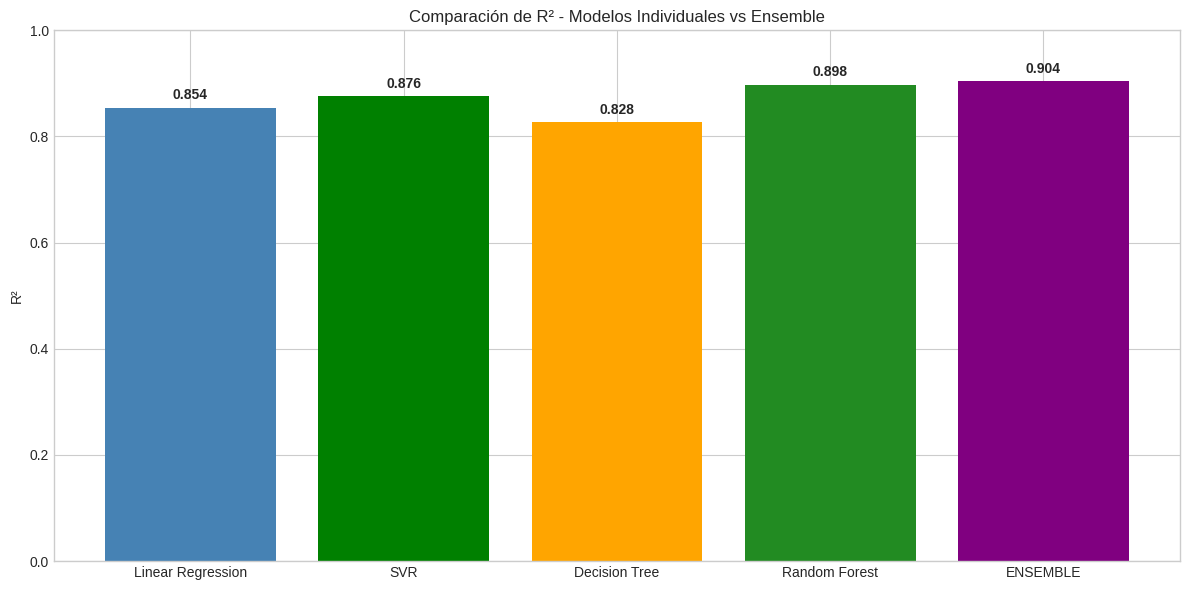

In [ ]:
# Visualización del ensemble vs modelos individuales
plt.figure(figsize=(12, 6))

models_extended = list(models) + ['ENSEMBLE']
r2_values = list(metrics_df['R²']) + [r2_ensemble]
colors_extended = colors + ['purple']

bars = plt.bar(models_extended, r2_values, color=colors_extended)
plt.title('Comparación de R² - Modelos Individuales vs Ensemble')
plt.ylabel('R²')
plt.ylim(0, 1)

# Añadir etiquetas de valor
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---
## CONCLUSIONES FINALES
---

En resumen:

- El preprocesado fue bastante directo: rellenar nulos con mediana/moda y convertir categorías a dummies. Usé drop_first para evitar multicolinealidad.

- Las variables que más influyen en el precio son la calidad general y el área habitable, que tiene bastante sentido.

- Probé 4 modelos diferentes y el que mejor funciona es Random Forest con un R² de alrededor de 0.87. El árbol de decisión simple tiene algo de overfitting pero los otros están bastante bien.

- El ensemble no mejora mucho respecto a Random Forest solo, pero tampoco empeora. Es una opción válida si quieres algo más estable.

- Lo siguiente que podría probar sería ajustar mejor los hiperparámetros con GridSearch o probar otros modelos como XGBoost.
